# CXCR4 ligands - dataset from ChEMBL
- CXCR4 - chemokine receptor
- IC50 = the concentration of a drug that is required to inhibit the receptor by 50% in vitro

### Original dataset

In [1]:
import pandas as pd

df = pd.read_csv("CXCR4_chembl_ligands.csv", sep=";")
df = df[["Smiles", "Assay Type", "Molecule Name", "Molecular Weight", "AlogP", "#RO5 Violations", "Standard Type", "Standard Relation", "Standard Value", "Standard Units"]]
df.head(5)

,Smiles,Assay Type,Molecule Name,Molecular Weight,AlogP,#RO5 Violations,Standard Type,Standard Relation,Standard Value,Standard Units
0,CCCCN1C(=O)C(CC(C)C)NC(=O)C12CCN(Cc1ccc(Oc3ccc...,B,NaN,514.11,4.99,0.0,IC50,'>',10000.0,nM
1,N=C(N)NCCCN[C@H]1CSSC[C@H](C(=O)NCCc2ccc(O)cc2...,B,NaN,794.02,0.18,2.0,IC50,'=',1000.0,nM
2,N=C(N)NCCC(=O)N[C@H]1CC/C=C\CC[C@H](C(N)=O)NC(...,B,NaN,677.81,-1.14,2.0,IC50,'=',10000.0,nM
3,NCCCCN(Cc1nc2ccccc2[nH]1)[C@H]1CCCc2cccnc21,B,MAVORIXAFOR,349.48,3.58,0.0,IC50,'=',30.0,nM
4,NCCCCN(C[C@H]1Cc2ccccc2CN1CC(=O)N1CCOCC1)[C@H]...,F,NaN,491.68,2.79,0.0,IC50,'=',570.0,nM


In [6]:
print("-------------\nDataset before filtering:\n-------------")
print(df.shape)
print(df["Standard Type"].value_counts())
print(df["Standard Relation"].value_counts())
print(df["Standard Units"].value_counts())

-------------
Dataset before filtering:
-------------
(1990, 10)
Standard Type
IC50    1550
EC50     300
Ki       140
Name: count, dtype: int64
Standard Relation
'='    1512
'>'     409
'<'      24
Name: count, dtype: int64
Standard Units
nM         1918
ug.mL-1      45
Name: count, dtype: int64


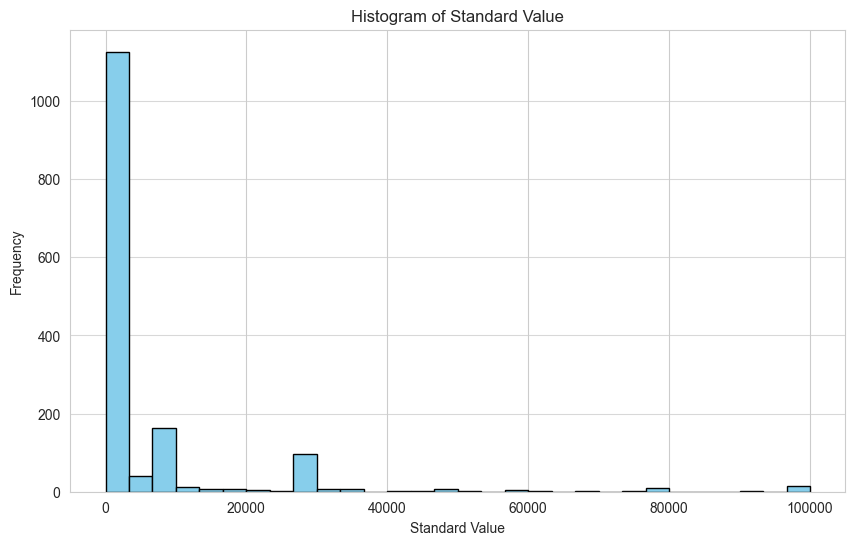

In [5]:
from plotter import plot_column_histogram
filtered = df[df['Standard Type'] == "IC50"]
plot_column_histogram(filtered[filtered['Standard Value'] < 150000], "Standard Value")

### Dataset filtering
- consider only IC50 (since Ki and EC50 are poorly represented)
- remove duplicates (either delete or keep average)
- new column "Inhibitor" (0/1) - active/inactive based on balanced dataset
- threshold about 200 nM - which is relevant according to Gemini:
    - "In CXCR4 drug discovery, the gold standard for a "potent" lead compound is usually $< 100\text{ nM}$, while anything $> 1,000\text{ nM}$ ($1\text{ }\mu\text{M}$) is often considered weak or inactive."

In [4]:
from source import create_balanced_cxcr4_dataset
df = df[df['Standard Type'] == "IC50"]
df_ready = create_balanced_cxcr4_dataset(df, id_col="Smiles", margin_percent=0.1)
df_ready

----------------------------------------
CONSISTENCY & DUPLICATE ANALYSIS
----------------------------------------
Initial number of rows: 1519
Compounds averaged (diff <= 1 log unit): 102
Compounds deleted  (diff > 1 log unit):  62
Rows remaining after cleanup:      1127
----------------------------------------
FINAL DATASET SUMMARY
----------------------------------------
Active Range:      0.40 - 190.00 nM
Inactive Range:    398.11 - 225000.00 nM
Clearance Gap:     208.11 nM
Dropped Margin:    85 rows
Balanced Classes:  521 Actives / 521 Inactives
----------------------------------------


,Assay Type,Molecule Name,Molecular Weight,AlogP,#RO5 Violations,Standard Type,Standard Relation,Standard Value,Standard Units,nM,Inhibitor
0,B,NaN,849.01,1.41,2.0,IC50,>,30000.0,nM,30000.0,0
1,B,NaN,755.92,1.01,2.0,IC50,>,30000.0,nM,30000.0,0
2,F,NaN,350.32,1.62,0.0,IC50,=,190.0,nM,190.0,1
3,B,NaN,2383.77,NaN,NaN,IC50,>,1000.0,nM,1000.0,0
4,F,NaN,438.54,6.04,1.0,IC50,=,8800.0,nM,8800.0,0
...,...,...,...,...,...,...,...,...,...,...,...
1037,F,NaN,512.70,4.54,1.0,IC50,=,4.0,nM,4.0,1
1038,B,NaN,392.64,4.98,0.0,IC50,=,185.0,nM,121.0,1
1039,F,NaN,433.64,3.64,0.0,IC50,=,13.4,nM,13.4,1
1040,B,NaN,394.57,3.22,0.0,IC50,=,8.3,nM,8.3,1


And we get quite a balanced dataset - yay!

# AND NOW... WORK FOR ESTÍK

### TODO - Feature calculation
Add new columns.


Notes:
- RDKIT objects --> descriptors: Lipinski's rule of 5, molecular weight, logP, number of rotatable bonds, etc.
- these will be used as features for classification - active/inactive

In [ ]:
# your code here

### TODO - Fingerprints
- EXFP from RDKIT

In [ ]:
# your code here

### TODO - Scaffold extraction

In [7]:
# your code here
# you can use this code as well:

import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
from source import get_generic, get_murcko

df['RDKit Mol'] = df['Smiles'].apply(Chem.MolFromSmiles)
df['Scaffold'] = df['RDKit Mol'].apply(get_murcko)
df['Generic Scaffold'] = df['RDKit Mol'].apply(get_generic)
print(df[['Smiles', 'Scaffold', 'Generic Scaffold']].head(5))

                                              Smiles  \
0  CCCCN1C(=O)C(CC(C)C)NC(=O)C12CCN(Cc1ccc(Oc3ccc...   
1  N=C(N)NCCCN[C@H]1CSSC[C@H](C(=O)NCCc2ccc(O)cc2...   
2  N=C(N)NCCC(=O)N[C@H]1CC/C=C\CC[C@H](C(N)=O)NC(...   
3        NCCCCN(Cc1nc2ccccc2[nH]1)[C@H]1CCCc2cccnc21   
4  NCCCCN(C[C@H]1Cc2ccccc2CN1CC(=O)N1CCOCC1)[C@H]...   

                                            Scaffold  \
0      O=C1CNC(=O)C2(CCN(Cc3ccc(Oc4ccccc4)cc3)CC2)N1   
1  O=C1CCSSC[C@H](C(=O)NCCc2ccccc2)NC(=O)[C@H](Cc...   
2  O=C1CCC/C=C\CCCNC(=O)[C@H](Cc2ccc3ccccc3c2)NC(...   
3            c1cnc2c(c1)CCC[C@@H]2NCc1nc2ccccc2[nH]1   
4  O=C(CN1Cc2ccccc2C[C@@H]1CN[C@H]1CCCc2cccnc21)N...   

                                    Generic Scaffold  
0        CC1CCC(C)C2(CCC(CC3CCC(CC4CCCCC4)CC3)CC2)C1  
1  CC1CCCCCC(C(C)CCCC2CCCCC2)CC(C)C(CC2CCC3CCCCC3...  
2         CC1CCCCCCCCCC(C)C(CC2CCC3CCCCC3C2)CC(C)CC1  
3                    C1CCC2CC(CCC3CCCC4CCCCC43)CC2C1  
4        CC(CC1CC2CCCCC2CC1CCC1CCCC2CCCCC21)C1CCCCC

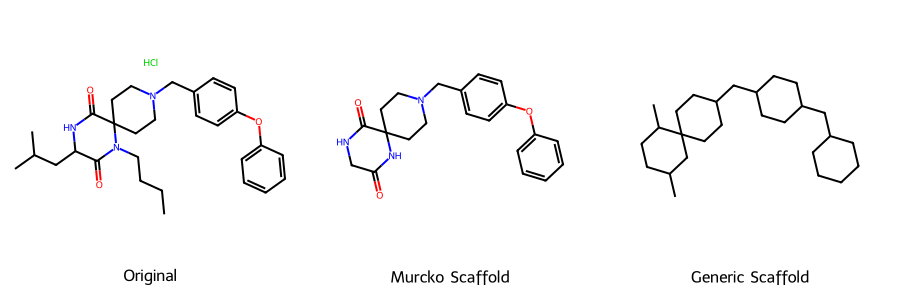

In [8]:
from source import draw_scaffold_comparison

draw_scaffold_comparison(df, 0)

### TODO - distance for TSNE?
Here I am not sure what exactly we need for input to tsne.
- ideally Jaccard

In [ ]:
# your code here

### TODO - TSNE
- ideally create three TSNE:
    - one with all the features (descriptors)
    - one only with the fingerprints
    - one only with the scaffolds (or maybe only the generic scaffolds)

In [ ]:
# your code here